# Post-Fire Landslide Susceptibility Modeling — Nacimiento, Chile
### Weighted Overlay Model

**Author:** Constanza Morales Gajardo
<!-- **Part of:** Landslide Susceptibility Portfolio Project (P5) -->

## 1. Introduction

This notebook combines the four conditioning variables derived in previous sessions — dNBR (burn severity), slope, geology, and land use/land cover — into a single post-fire landslide susceptibility index using a weighted overlay (multicriteria analysis) approach.

- **Study area:** Nacimiento commune, Chile
- **Method:** Weighted overlay, with weights informed by landslide susceptibility literature
- **Input layers:** 
  - `nacimiento_dnbr.tif` (continuous, requires reclassification)
  - `nacimiento_slope_reclass.tif` (5 classes)
  - `nacimiento_geology_reclass.tif` (5 classes)
  - `nacimiento_landuse_reclass.tif` (5 classes)
- **Tools:** rasterio, numpy, matplotlib

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.plot import show

print("Libraries imported successfully")

Libraries imported successfully


## 2. Load Conditioning Variable Layers

Note: dNBR was exported in Session 1 as a continuous raster (not reclassified), since its reclassification into susceptibility classes is more naturally performed here, at the integration stage, alongside the final combination of all four variables. Slope, geology, and land use were already reclassified in their respective sessions (2 and 3).

In [2]:
# Load all four conditioning variable rasters
dnbr_path = '../data/raw/nacimiento_dnbr.tif'
slope_path = '../data/raw/nacimiento_slope_reclass.tif'
geology_path = '../data/raw/nacimiento_geology_reclass.tif'
landuse_path = '../data/raw/nacimiento_landuse_reclass.tif'

with rasterio.open(dnbr_path) as src:
    dnbr = src.read(1)
    dnbr_meta = src.meta
    dnbr_nodata = src.nodata

with rasterio.open(slope_path) as src:
    slope = src.read(1)
    slope_meta = src.meta

with rasterio.open(geology_path) as src:
    geology = src.read(1)
    geology_meta = src.meta

with rasterio.open(landuse_path) as src:
    landuse = src.read(1)
    landuse_meta = src.meta

print("All four layers loaded")
print(f"dNBR shape: {dnbr.shape}")
print(f"Slope shape: {slope.shape}")
print(f"Geology shape: {geology.shape}")
print(f"Land use shape: {landuse.shape}")

All four layers loaded
dNBR shape: (1974, 2650)
Slope shape: (1317, 1767)
Geology shape: (1315, 1765)
Land use shape: (3948, 5298)


## 3. Align Rasters to a Common Grid

Since the four layers were exported at different resolutions and slightly different extents, they must be resampled to match a single reference grid before they can be combined pixel-by-pixel. Slope (30m, SRTM-derived) is used as the reference grid, since it matches the resolution most commonly used in the source literature for post-fire landslide susceptibility.

In [3]:
from rasterio.warp import reproject, Resampling

# Use slope as the reference grid (30m resolution)
reference_meta = slope_meta
reference_shape = slope.shape
reference_transform = slope_meta['transform']
reference_crs = slope_meta['crs']

def align_to_reference(source_path, reference_transform, reference_crs, reference_shape):
    with rasterio.open(source_path) as src:
        aligned = np.zeros(reference_shape, dtype=np.float32)
        reproject(
            source=rasterio.band(src, 1),
            destination=aligned,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=reference_transform,
            dst_crs=reference_crs,
            resampling=Resampling.nearest
        )
    return aligned

# Align dNBR and land use to slope's grid (geology already matches slope's grid)
dnbr_aligned = align_to_reference(dnbr_path, reference_transform, reference_crs, reference_shape)
landuse_aligned = align_to_reference(landuse_path, reference_transform, reference_crs, reference_shape)

print(f"dNBR aligned shape: {dnbr_aligned.shape}")
print(f"Land use aligned shape: {landuse_aligned.shape}")
print(f"Slope shape (reference): {slope.shape}")
print(f"Geology shape: {geology.shape}")

dNBR aligned shape: (1317, 1767)
Land use aligned shape: (1317, 1767)
Slope shape (reference): (1317, 1767)
Geology shape: (1315, 1765)


In [4]:
# Geology also needs alignment to the reference grid
geology_aligned = align_to_reference(geology_path, reference_transform, reference_crs, reference_shape)

print(f"Geology aligned shape: {geology_aligned.shape}")
print(f"Matches reference: {geology_aligned.shape == slope.shape}")

Geology aligned shape: (1317, 1767)
Matches reference: True


## 4. Reclassify dNBR into Susceptibility Classes

dNBR is reclassified into 5 susceptibility classes using standard USGS burn severity thresholds, consistent with the classification used in the companion wildfire severity project (`nacimiento-wildfire-2023`).

| Class | dNBR range | Burn Severity | Susceptibility |
|-------|-----------|---------------|-----------------|
| 1 | < 0.1 | Unburned/Very Low | Very Low |
| 2 | 0.1 – 0.27 | Low Severity | Low |
| 3 | 0.27 – 0.44 | Moderate-Low Severity | Moderate |
| 4 | 0.44 – 0.66 | Moderate-High Severity | High |
| 5 | > 0.66 | High Severity | Very High |

In [5]:
# Reclassify dNBR into 5 susceptibility classes
dnbr_reclass = np.zeros_like(dnbr_aligned, dtype=np.uint8)

dnbr_reclass[dnbr_aligned < 0.1] = 1
dnbr_reclass[(dnbr_aligned >= 0.1) & (dnbr_aligned < 0.27)] = 2
dnbr_reclass[(dnbr_aligned >= 0.27) & (dnbr_aligned < 0.44)] = 3
dnbr_reclass[(dnbr_aligned >= 0.44) & (dnbr_aligned < 0.66)] = 4
dnbr_reclass[dnbr_aligned >= 0.66] = 5

print("dNBR reclassified into 5 susceptibility classes")
print(f"Unique values: {np.unique(dnbr_reclass)}")

dNBR reclassified into 5 susceptibility classes
Unique values: [1 2 3 4 5]


## 5. Weighted Overlay — Combine All Variables

The four reclassified variables are combined using the weights derived from landslide susceptibility literature (Session 4 introduction):

| Variable | Weight |
|----------|--------|
| Slope | 0.35 |
| dNBR | 0.30 |
| Geology | 0.20 |
| Land Use | 0.15 |

$$Susceptibility = (0.35 \times Slope) + (0.30 \times dNBR) + (0.20 \times Geology) + (0.15 \times LandUse)$$

In [6]:
# Define weights
w_slope = 0.35
w_dnbr = 0.30
w_geology = 0.20
w_landuse = 0.15

# Weighted overlay calculation
susceptibility_index = (
    w_slope * slope.astype(np.float32) +
    w_dnbr * dnbr_reclass.astype(np.float32) +
    w_geology * geology_aligned.astype(np.float32) +
    w_landuse * landuse_aligned.astype(np.float32)
)

print(f"Susceptibility index calculated")
print(f"Min value: {susceptibility_index.min():.2f}")
print(f"Max value: {susceptibility_index.max():.2f}")
print(f"Mean value: {susceptibility_index.mean():.2f}")

Susceptibility index calculated
Min value: 0.30
Max value: 3.85
Mean value: 1.11


## 6. Classify Final Susceptibility Index

The continuous susceptibility index (theoretical range: 1.0–5.0) is classified into 5 categorical susceptibility levels for interpretation and mapping.

In [7]:
# Classify continuous index into categorical susceptibility levels
susceptibility_class = np.zeros_like(susceptibility_index, dtype=np.uint8)

susceptibility_class[(susceptibility_index >= 1.0) & (susceptibility_index < 1.8)] = 1  # Very Low
susceptibility_class[(susceptibility_index >= 1.8) & (susceptibility_index < 2.6)] = 2  # Low
susceptibility_class[(susceptibility_index >= 2.6) & (susceptibility_index < 3.4)] = 3  # Moderate
susceptibility_class[(susceptibility_index >= 3.4) & (susceptibility_index < 4.2)] = 4  # High
susceptibility_class[susceptibility_index >= 4.2] = 5  # Very High

# Print class distribution
unique, counts = np.unique(susceptibility_class, return_counts=True)
total_pixels = susceptibility_class.size
print("Susceptibility class distribution:")
labels = {0: 'No data/masked', 1: 'Very Low', 2: 'Low', 3: 'Moderate', 4: 'High', 5: 'Very High'}
for cls, count in zip(unique, counts):
    pct = (count / total_pixels) * 100
    print(f"  Class {cls} ({labels.get(cls, 'Unknown')}): {count} pixels ({pct:.1f}%)")

Susceptibility class distribution:
  Class 0 (No data/masked): 1060995 pixels (45.6%)
  Class 1 (Very Low): 777271 pixels (33.4%)
  Class 2 (Low): 382147 pixels (16.4%)
  Class 3 (Moderate): 106055 pixels (4.6%)
  Class 4 (High): 671 pixels (0.0%)


## 7. Mask to Actual Nacimiento Boundary

The reprojection/alignment process operates on the bounding box of the grid, not the actual irregular polygon shape, leaving corner areas outside the commune with invalid (zero) values. Here we mask the result using the true Nacimiento boundary polygon.

In [8]:
import geopandas as gpd
from rasterio.features import geometry_mask

# Reload Nacimiento boundary (in case this is a fresh kernel session)
gadm_path = "../../nacimiento-wildfire-2023/data/raw/gadm41_CHL.gpkg"
chile_admin = gpd.read_file(gadm_path, layer='ADM_ADM_3')
nacimiento = chile_admin[chile_admin['NAME_3'] == 'Nacimiento']
nacimiento = nacimiento.to_crs(reference_crs)

# Create mask: True = outside boundary (to be masked out)
mask = geometry_mask(
    nacimiento.geometry,
    out_shape=reference_shape,
    transform=reference_transform,
    invert=False  # True where OUTSIDE the polygon
)

# Apply mask: set areas outside the boundary to 0
susceptibility_class_masked = susceptibility_class.copy()
susceptibility_class_masked[mask] = 0

# Print updated distribution
unique, counts = np.unique(susceptibility_class_masked, return_counts=True)
total_valid = counts[unique != 0].sum()
print("Susceptibility class distribution (masked to Nacimiento boundary):")
for cls, count in zip(unique, counts):
    if cls == 0:
        continue
    pct = (count / total_valid) * 100
    print(f"  Class {cls} ({labels.get(cls, 'Unknown')}): {count} pixels ({pct:.1f}%)")

Susceptibility class distribution (masked to Nacimiento boundary):
  Class 1 (Very Low): 776832 pixels (61.4%)
  Class 2 (Low): 382104 pixels (30.2%)
  Class 3 (Moderate): 106054 pixels (8.4%)
  Class 4 (High): 671 pixels (0.1%)


## 8. Known Limitation — Road Cut Slopes

This model does not explicitly account for artificial road cut slopes (taludes), which are geotechnically distinct from natural hillslopes: they are engineered cuts (often steeper than natural angle of repose), typically left with sparse or no vegetation, and subject to concentrated runoff from the adjacent roadway. Where road cuts fall within burned areas, they may combine both factors of elevated susceptibility.

The current model partially captures road cut susceptibility indirectly through slope and dNBR where applicable, but cannot isolate their specific engineered/anthropogenic nature or concentrated drainage effects. Explicitly modeling road cut slopes would require a higher-resolution DEM (road cuts are often only a few meters wide — well below SRTM's 30m resolution) combined with road network buffer analysis, which is beyond the scope of this project.

## 9. Visualize Final Susceptibility Map

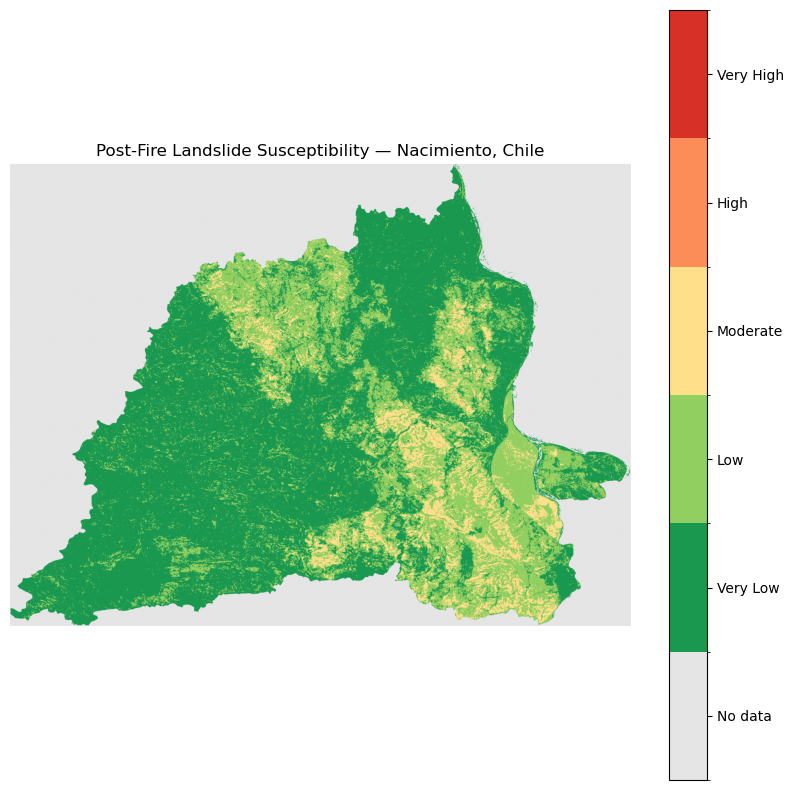

In [9]:
# Visualization with custom colormap
from matplotlib.colors import ListedColormap, BoundaryNorm

colors = ['#e5e5e5', '#1a9850', '#91cf60', '#fee08b', '#fc8d59', '#d73027']
cmap = ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(susceptibility_class_masked, cmap=cmap, norm=norm)
cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2, 3, 4, 5])
cbar.ax.set_yticklabels(['No data', 'Very Low', 'Low', 'Moderate', 'High', 'Very High'])
ax.set_title('Post-Fire Landslide Susceptibility — Nacimiento, Chile')
ax.axis('off')
plt.show()

## 10. Export Final Susceptibility Map

Exporting the final classified susceptibility raster as a static GeoTIFF to `outputs/`.

**Note on results:** the maximum susceptibility index obtained was 3.85 (out of a theoretical maximum of 5.0), and no pixels fell into the "Very High" category. This indicates that, within Nacimiento commune, the most extreme conditions across all four variables (steepest slopes, highest burn severity, weakest geology, and least vegetative cover) do not spatially coincide at any single location — a finding in itself, rather than a modeling limitation.

In [10]:
# Export final susceptibility classification as GeoTIFF
output_path = '../outputs/nacimiento_landslide_susceptibility.tif'

output_meta = reference_meta.copy()
output_meta.update({
    'dtype': 'uint8',
    'count': 1,
    'nodata': 0
})

with rasterio.open(output_path, 'w', **output_meta) as dst:
    dst.write(susceptibility_class_masked, 1)

print(f"Final susceptibility map exported to: {output_path}")

Final susceptibility map exported to: ../outputs/nacimiento_landslide_susceptibility.tif


## Conclusions

- Four conditioning variables (dNBR, slope, geology, land use) were successfully combined into a single post-fire landslide susceptibility index using weighted overlay analysis, with weights informed by landslide susceptibility literature (Slope 0.35, dNBR 0.30, Geology 0.20, Land Use 0.15).
- All layers were aligned to a common 30m grid and masked to the true Nacimiento commune boundary before combination.
- dNBR was reclassified into susceptibility classes at this stage (Session 4), following USGS burn severity thresholds.
- **Result distribution:** Very Low (61.4%), Low (30.2%), Moderate (8.4%), High (0.1%), Very High (0%).
- The absence of "Very High" susceptibility areas indicates that the most extreme conditions across all four variables do not spatially coincide within the study area — a genuine finding rather than a modeling artifact.
- **Known limitation:** artificial road cut slopes are not explicitly modeled, as this would require a higher-resolution DEM than SRTM (30m) to resolve features only a few meters wide.
- **Known limitation:** the geology layer (GLiM) has a coarse average scale (~1:3,750,000), which may underrepresent fine-scale lithological heterogeneity.
- Final classified susceptibility map exported to `outputs/nacimiento_landslide_susceptibility.tif`.
- **Next step (Session 5):** build the final interactive map (Folium), write the project README, and publish to GitHub Pages.